# NumCompute-Stream Demo

Assignment 2.2: Streaming Machine Learning Framework

This notebook demonstrates:

- Loading a CSV dataset using the custom `io.py` module
- Splitting data into chunks
- Incremental preprocessing using `partial_fit`
- Streaming Decision Tree training
- Streaming Ensemble training
- StreamTrainer logging
- Visualising streaming accuracy over time

## 1. Import Required Modules

In [31]:
import sys
import os
import numpy as np

PROJECT_ROOT = r"C:\Users\91810\Downloads\numcompute_submission\NumCompute"
sys.path.append(PROJECT_ROOT)

from numcompute import io as nc_io
from numcompute.preprocessing import StandardScaler, SimpleImputer
from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import EnsembleClassifier
from numcompute.stream import StreamTrainer
from numcompute.visualise import compare_models
from numcompute.utils import batch_iter

## 2. Load Dataset Using Custom I/O Pipeline

In [32]:
csv_path = os.path.join(PROJECT_ROOT, "demo", "sample.csv")

data = nc_io.load_csv(csv_path, skip_header=True)

X = data[:, :-1]
y = data[:, -1].astype(int)

print("Dataset shape:", data.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.bincount(y))

Dataset shape: (12, 4)
X shape: (12, 3)
y shape: (12,)
Class distribution: [6 6]


## 3. Simulate Streaming Data Chunks

In [33]:
chunks = list(batch_iter(X, batch_size=3, y=y))

print("Number of chunks:", len(chunks))

for i, (X_chunk, y_chunk) in enumerate(chunks):
    print(f"Chunk {i+1}: X={X_chunk.shape}, y={y_chunk.shape}")

Number of chunks: 4
Chunk 1: X=(3, 3), y=(3,)
Chunk 2: X=(3, 3), y=(3,)
Chunk 3: X=(3, 3), y=(3,)
Chunk 4: X=(3, 3), y=(3,)


## 4. Incremental Pipeline Preprocessing

The imputer and scaler act as the preprocessing pipeline. Both are updated incrementally on streaming chunks before model training.

In [34]:
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()

for X_chunk, y_chunk in chunks:
    imputer.partial_fit(X_chunk)

X_imputed = imputer.transform(X)

imputed_chunks = list(batch_iter(X_imputed, batch_size=3, y=y))

for X_chunk, y_chunk in imputed_chunks:
    scaler.partial_fit(X_chunk)

X_scaled = scaler.transform(X_imputed)

scaled_chunks = list(batch_iter(X_scaled, batch_size=3, y=y))

print("Scaled feature means:", X_scaled.mean(axis=0))
print("Scaled feature std:", X_scaled.std(axis=0))

Scaled feature means: [-5.66676335e-17  5.08852220e-17 -1.96601994e-16]
Scaled feature std: [1. 1. 1.]


## 5. Streaming Decision Tree Training

In [35]:
tree = DecisionTreeClassifier(
    max_depth=3,
    criterion="gini"
)

tree_accuracy = []

for X_chunk, y_chunk in scaled_chunks:
    tree.partial_fit(X_chunk, y_chunk)

    y_pred = tree.predict(X_chunk)

    acc = np.mean(y_pred == y_chunk)

    tree_accuracy.append(acc)

print("Decision Tree accuracy by chunk:")
print(tree_accuracy)

print("Average Decision Tree accuracy:")
print(np.mean(tree_accuracy))

Decision Tree accuracy by chunk:
[1.0, 1.0, 1.0, 1.0]
Average Decision Tree accuracy:
1.0


## 6. Streaming Ensemble Training

In [36]:
ensemble = EnsembleClassifier(
    n_estimators=5,
    max_depth=3,
    random_state=42
)

ensemble_accuracy = []

for X_chunk, y_chunk in scaled_chunks:
    ensemble.partial_fit(X_chunk, y_chunk)

    y_pred = ensemble.predict(X_chunk)

    acc = np.mean(y_pred == y_chunk)

    ensemble_accuracy.append(acc)

print("Ensemble accuracy by chunk:")
print(ensemble_accuracy)

print("Average Ensemble accuracy:")
print(np.mean(ensemble_accuracy))

Ensemble accuracy by chunk:
[1.0, 1.0, 1.0, 1.0]
Average Ensemble accuracy:
1.0


## 7. StreamTrainer Logging

In [37]:
trainer = StreamTrainer(
    DecisionTreeClassifier(max_depth=3)
)

for X_chunk, y_chunk in scaled_chunks:
    trainer.fit_chunk(X_chunk, y_chunk)

logs = trainer.get_logs()

for log in logs:
    print(log)

print("Total logged chunks:", len(logs))

{'chunk': 1, 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'n_samples': 3, 'memory_bytes': 132}
{'chunk': 2, 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'n_samples': 3, 'memory_bytes': 216}
{'chunk': 3, 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'n_samples': 3, 'memory_bytes': 300}
{'chunk': 4, 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'n_samples': 3, 'memory_bytes': 384}
Total logged chunks: 4


## 8. Visualisation of Streaming Metrics

Note: The Decision Tree and Ensemble curves overlap because both models achieved identical accuracy on this small demonstration dataset.

Decision Tree: [1.0, 1.0, 1.0, 1.0]
Ensemble: [1.0, 1.0, 1.0, 1.0]


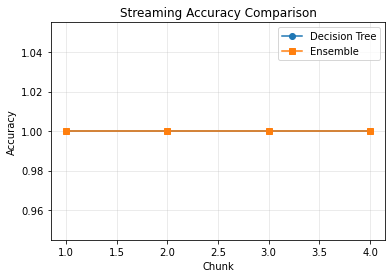

(<Figure size 432x288 with 1 Axes>,
 <AxesSubplot:title={'center':'Streaming Accuracy Comparison'}, xlabel='Chunk', ylabel='Accuracy'>)

In [39]:
print("Decision Tree:", tree_accuracy)
print("Ensemble:", ensemble_accuracy)

compare_models(
    tree_accuracy,
    ensemble_accuracy,
    labels=("Decision Tree", "Ensemble"),
    title="Streaming Accuracy Comparison",
    ylabel="Accuracy",
)

## 9. Results Summary



The streaming machine learning framework was successfully demonstrated using the NumCompute package.

Key outcomes:

- Dataset was loaded from CSV using the custom `io.py` module.
- Data was divided into multiple chunks to simulate a streaming environment.
- Missing values were handled using `SimpleImputer`.
- `StandardScaler` was updated incrementally using `partial_fit()`.
- `DecisionTreeClassifier` supported streaming training through `partial_fit()`.
- `EnsembleClassifier` supported incremental ensemble learning.
- `StreamTrainer` recorded chunk accuracy, cumulative accuracy, memory usage, and sample counts.
- `visualise.py` was used to compare model performance across streaming chunks.

The sample CSV is small for demonstration purposes; the focus is on verifying the streaming workflow rather than maximising predictive performance.